In [1]:
import yfinance as yf
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [2]:
# os.makedirs("./data", exist_ok=True)
# prices = yf.download(["SPY", "GLD", "GDX", "TLT", "^VIX"], start="2010-01-01", auto_adjust=True, progress=False)["Close"]
# prices.to_pickle("./data/prices.pkl")
prices = pd.read_pickle("./data/prices.pkl")

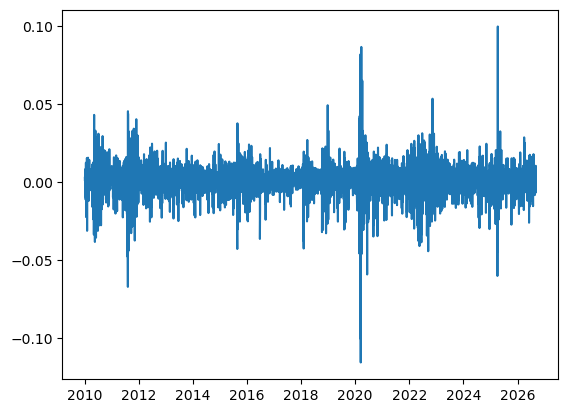

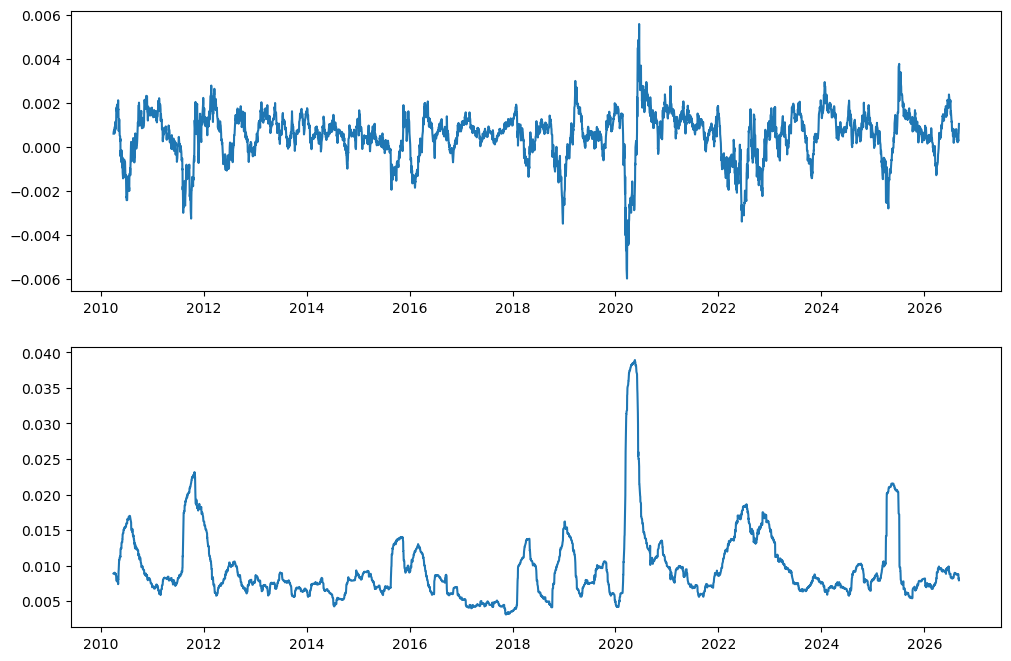

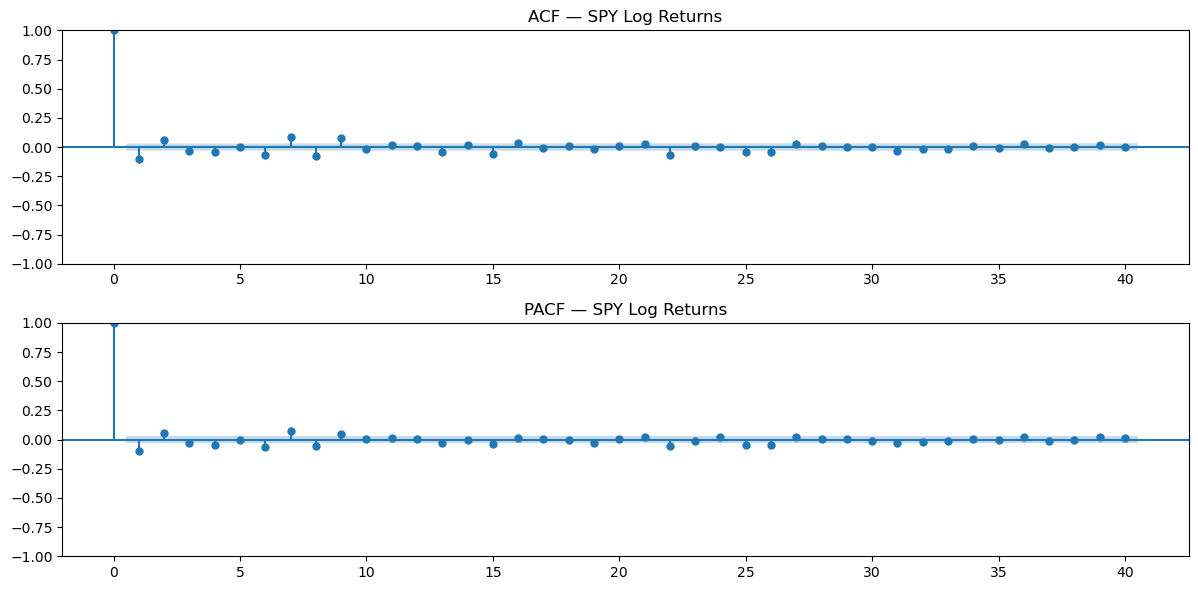

In [5]:
spy = prices[["SPY"]].copy()
spy['log_returns'] = np.log(spy["SPY"] / spy["SPY"].shift(1))
spy = spy.dropna()
plt.plot(spy["log_returns"])
plt.show()


fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(spy['log_returns'].rolling(60).mean())
axes[1].plot(spy['log_returns'].rolling(60).std())

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

spy_returns = spy['log_returns']
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

plot_acf( spy_returns, ax=axes[0], lags=40, alpha=0.05, title="ACF — SPY Log Returns")
plot_pacf(spy_returns, ax=axes[1], lags=40, alpha=0.05, title="PACF — SPY Log Returns")

plt.tight_layout()
plt.show()

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

candidates = [(0,0,0), (1,0,0), (0,0,1), (1,0,1)]

results = []
for order in candidates:
    model = ARIMA(spy_returns, order=order).fit()
    results.append({
        "order"  : order,
        "AIC"    : model.aic,
        "BIC"    : model.bic,
        "params" : model.params.to_dict()
    })

results_df = pd.DataFrame(results).set_index("order")
print(results_df[["AIC", "BIC"]])

                    AIC           BIC
order                                
(0, 0, 0) -26084.088721 -26071.406854
(1, 0, 0) -26124.578747 -26105.555947
(0, 0, 1) -26120.422501 -26101.399701
(1, 0, 1) -26126.456231 -26101.092498


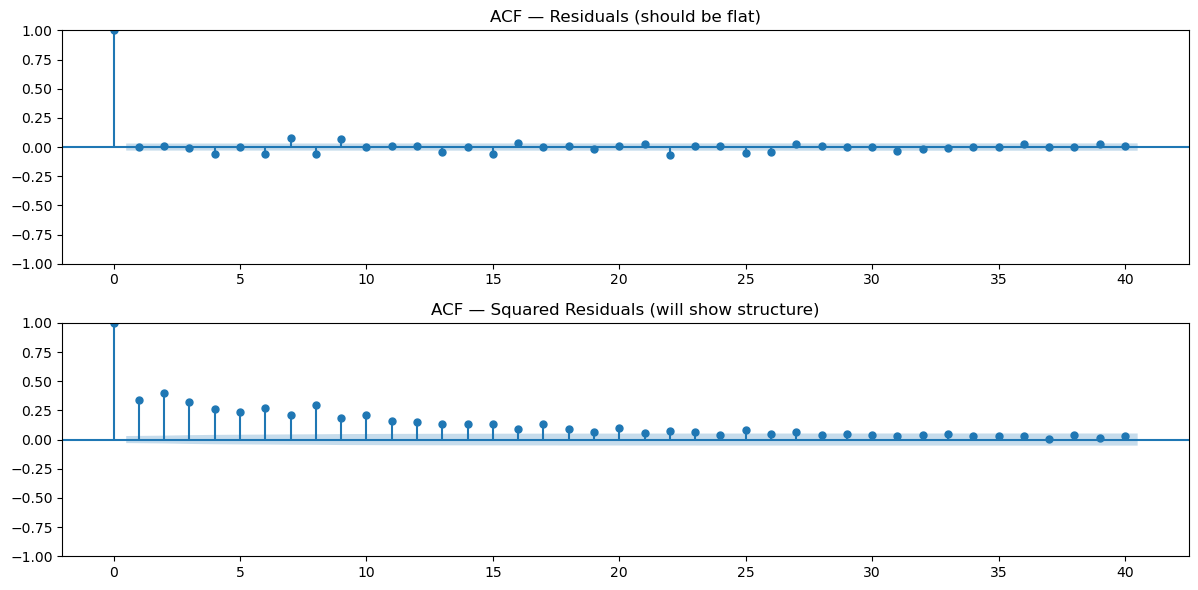

In [ ]:
model = ARIMA(spy_returns, order=(1,0,1)).fit()
residuals = pd.Series(model.resid, index=spy_returns.index, name="residuals")

fig, axes = plt.subplots(2, 1, figsize=(12, 6))

plot_acf(residuals,    ax=axes[0], lags=40, alpha=0.05, title="ACF — Residuals (should be flat)")
plot_acf(residuals**2, ax=axes[1], lags=40, alpha=0.05, title="ACF — Squared Residuals (will show structure)")

plt.tight_layout()
plt.show()

# Volatility Analysis

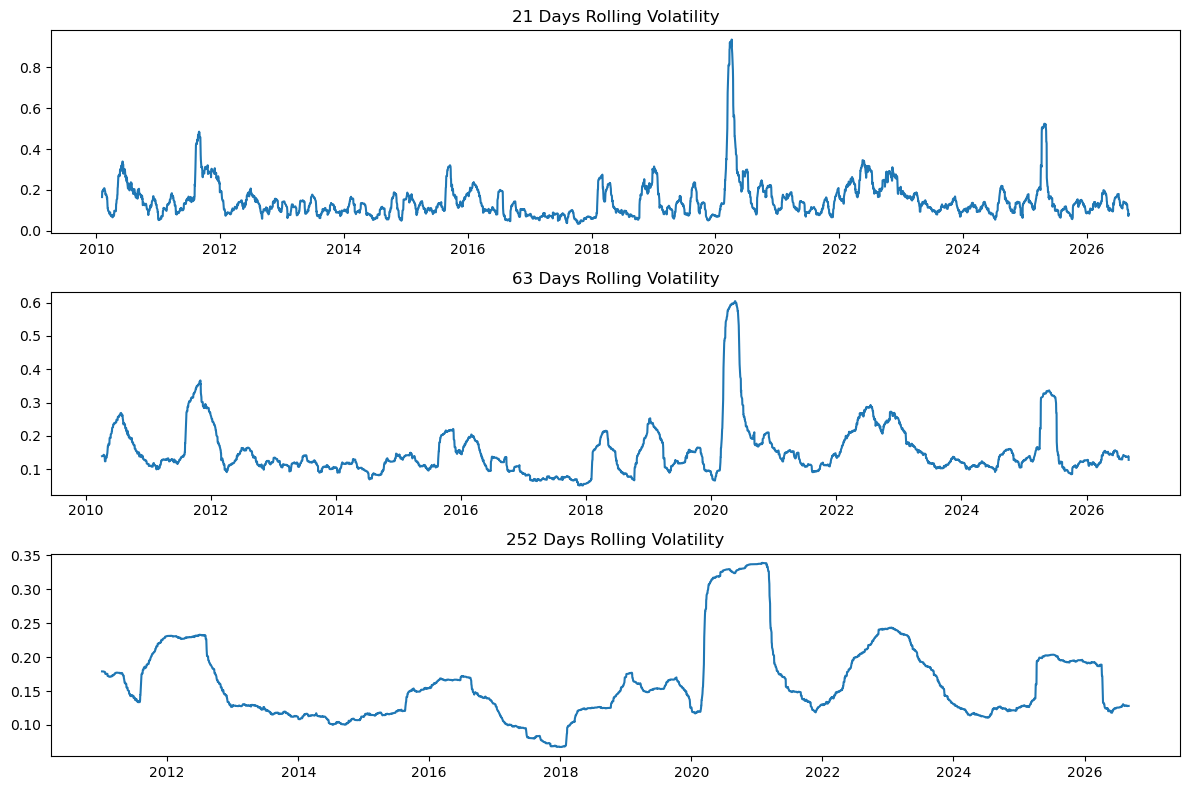

In [13]:
prices = pd.read_pickle("./data/prices.pkl")
spy = prices[["SPY"]].copy()
spy['log_returns'] = np.log(spy["SPY"] / spy["SPY"].shift(1))
spy = spy.dropna()
windows = [21, 63, 252]
for w in windows:
    col = f'{w}_volatility'
    spy[col] = spy['log_returns'].rolling(w).std()*np.sqrt(252)

fig, axes = plt.subplots(3, 1, figsize = (12,8))

ax = axes.flatten()
for i, w in enumerate(spy.columns[2:]):
    ax[i].plot(spy[w])
    ax[i].set_title(f"{w.replace('_volatility', '').strip()} Days Rolling Volatility")

plt.tight_layout()
plt.show()

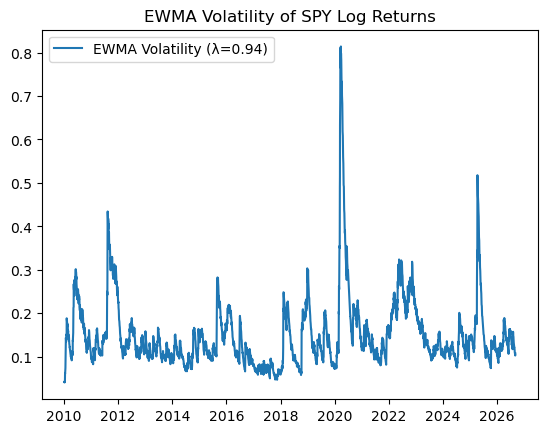

In [18]:
def ewma_volatility(returns, lam=0.94):
    sigma2 = np.zeros(len(returns))
    sigma2[0] = returns[0]**2
    for t in range(1, len(returns)):
        sigma2[t] = (1-lam) * returns[t-1]**2 + lam * sigma2[t-1]

    return pd.Series(np.sqrt(sigma2)*np.sqrt(252), index = returns.index, name="EWMA Volatility")

ewma_vol = ewma_volatility(spy['log_returns'])
plt.plot(ewma_vol, label="EWMA Volatility (λ=0.94)")
plt.legend()
plt.title("EWMA Volatility of SPY Log Returns")
plt.show()

In [ ]:
from scipy.optimize import minimize

def log_likelihood(params, returns):
    w, alpha, beta = params
    if w <= 0 or alpha < 0 or beta < 0 or alpha + beta >= 1:
        return 1e10
    sigma2 = np.zeros(len(returns))
    sigma2[0] = w / (1 - alpha - beta)
    T = len(returns)
    for i in range(1, T):
        sigma2[i] = w + alpha * returns[i-1]**2 + beta * sigma2[i-1]
    if np.any(sigma2 <= 0):
        return 1e10
    log_lik = -0.5 * np.sum(np.log(sigma2) + returns**2 / sigma2)
    return -log_lik

def fit_GARCH(returns):
    var = returns.var()
    init_params = [var * 0.05, 0.05, 0.90]

    bounds = [
        (1e-8, None),   # omega > 0
        (1e-8, 0.999),  # alpha
        (1e-8, 0.999),  # beta
    ]

    result = minimize(
        log_likelihood,
        init_params,
        args=(returns.values,),
        method='L-BFGS-B',
        bounds=bounds,
        options={'ftol': 1e-12, 'gtol': 1e-8, 'maxiter': 2000}
    )
    return result

def garch_vol(params, returns):
    w, alpha, beta = params
    sigma2 = np.zeros(len(returns))
    sigma2[0] = w / (1 - alpha - beta)
    for i in range(1, len(returns)):
        sigma2[i] = w + alpha * returns[i-1]**2 + beta * sigma2[i-1]
    return pd.Series(np.sqrt(sigma2) * np.sqrt(252),
                     index=returns.index,
                     name='GARCH')

returns = spy['log_returns']
result = fit_GARCH(returns)

print(f"Omega        : {result.x[0]:.8f}")
print(f"Alpha        : {result.x[1]:.6f}")
print(f"Beta         : {result.x[2]:.6f}")
print(f"Alpha + Beta : {result.x[1] + result.x[2]:.6f}")
print(f"Long run vol : {np.sqrt(result.x[0]/(1-result.x[1]-result.x[2])*252):.4f}")
print(f"Converged    : {result.success}")
print(f"Message      : {result.message}")
print(f"Final -loglik: {result.fun:.4f}")

garch_volatility = garch_vol(result.x, spy['log_returns'])

Omega        : 0.00000378
Alpha        : 0.149743
Beta         : 0.814209
Alpha + Beta : 0.963952
Long run vol : 0.1627
Converged    : True
Message      : CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Final -loglik: -17752.0532


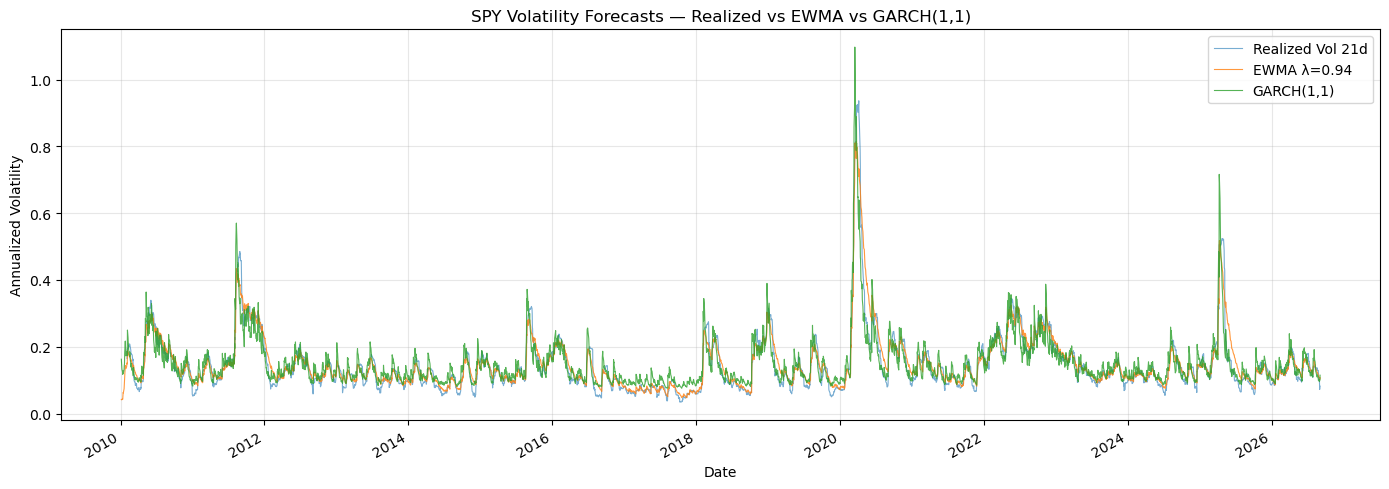

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))

# Realized volatility — 21 day
spy['21_volatility'].plot(ax=ax, label='Realized Vol 21d', 
                          alpha=0.6, linewidth=0.8)

# EWMA
ewma_vol.plot(ax=ax, label='EWMA λ=0.94', 
              alpha=0.8, linewidth=0.8)

# GARCH
garch_volatility.plot(ax=ax, label='GARCH(1,1)', 
                      alpha=0.8, linewidth=0.8)

ax.set_title("SPY Volatility Forecasts — Realized vs EWMA vs GARCH(1,1)")
ax.set_ylabel("Annualized Volatility")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()